# Создание маски

Импорт библиотек

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Метод 1: Морфология

In [3]:
img = cv2.imread("input.jpeg")

# Перевод в цветовое пространство HSV
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# Выделение желтого цвета
lower_yellow = np.array([15, 40, 40])
upper_yellow = np.array([30, 255, 255])
mask_yellow = cv2.inRange(hsv, lower_yellow, upper_yellow)

# Выделение синего цвета (для надписи внутри объекта)
lower_blue = np.array([90, 40, 40])
upper_blue = np.array([130, 255, 255])
mask_blue = cv2.inRange(hsv, lower_blue, upper_blue)

# Объединение масок
combined_mask = cv2.bitwise_or(mask_yellow, mask_blue)

# Фильтрация шумов и заполнение пустот
kernel_small = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
clean_mask = cv2.morphologyEx(combined_mask, cv2.MORPH_OPEN, kernel_small, iterations=1)

dilated = cv2.dilate(clean_mask, kernel_small, iterations=4)
mask_morph = cv2.erode(dilated, kernel_small, iterations=1)

cv2.imwrite("base_mask.png", mask_morph)

True

## Метод 2: GrabCut

In [4]:
mask_gc = np.zeros(img.shape[:2], np.uint8)

bgdModel = np.zeros((1, 65), np.float64)
fgdModel = np.zeros((1, 65), np.float64)

# Точные координаты объекта
rect = (339, 550, 231, 250)

cv2.grabCut(img, mask_gc, rect, bgdModel, fgdModel, 5, cv2.GC_INIT_WITH_RECT)
mask_grabcut = np.where((mask_gc == 2) | (mask_gc == 0), 0, 255).astype("uint8")

## Визуализация результатов

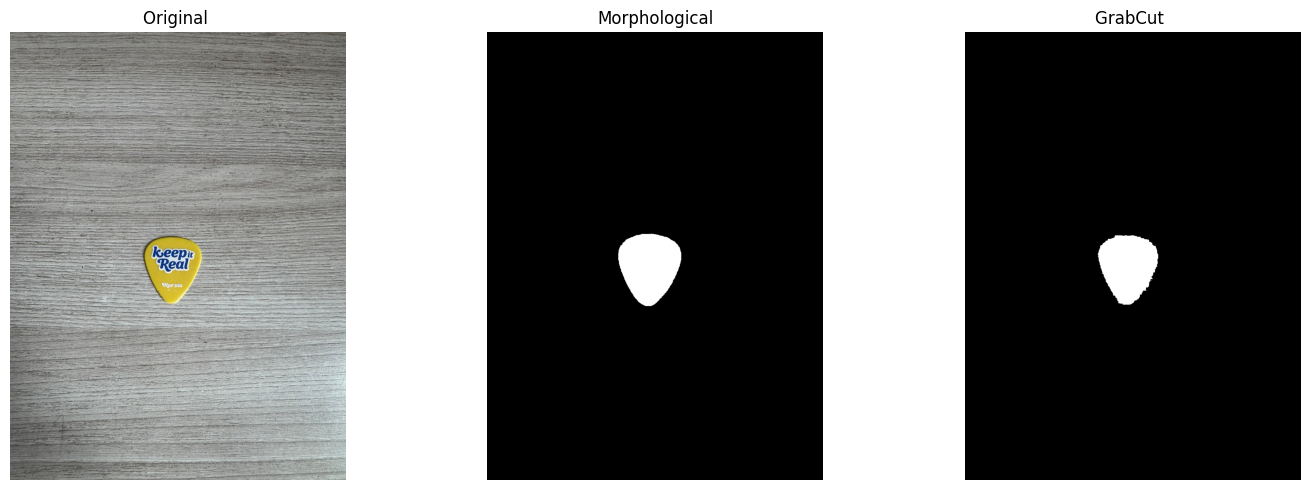

In [6]:
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title("Original ")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask_morph, cmap="gray")
plt.title("Morphological")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(mask_grabcut, cmap="gray")
plt.title("GrabCut ")
plt.axis("off")

plt.tight_layout()
plt.show()